In [58]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [59]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score

In [60]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Iris_data.csv")
df

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [61]:
df.head()

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [62]:
df.describe()

,5.1,3.5,1.4,0.2
count,149.000000,149.000000,149.000000,149.000000
mean,5.848322,3.051007,3.774497,1.205369
std,0.828594,0.433499,1.759651,0.761292
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [63]:
df.columns=['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Class']

In [64]:
df

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [65]:
x = df.iloc[:,:-1]
x

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,4.9,3.0,1.4,0.2
1,4.7,3.2,1.3,0.2
2,4.6,3.1,1.5,0.2
3,5.0,3.6,1.4,0.2
4,5.4,3.9,1.7,0.4
...,...,...,...,...
144,6.7,3.0,5.2,2.3
145,6.3,2.5,5.0,1.9
146,6.5,3.0,5.2,2.0
147,6.2,3.4,5.4,2.3


In [66]:
df.Class.unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [67]:
label={'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}
y=[label[a] for a in df.iloc[:,-1]]

In [68]:
y

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2]

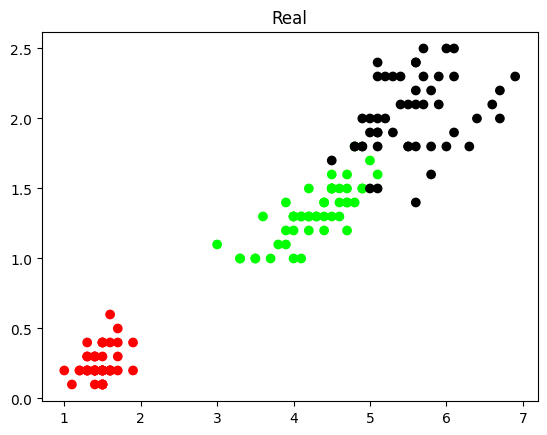

In [69]:
colormap=np.array(['red','lime','black'])
plt.title('Real')
plt.scatter(x.Petal_Length,x.Petal_Width,c=colormap[y])

In [70]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3,random_state=42)
km = model.fit(x)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [71]:
KMeans_label = km.predict(x)

In [72]:
KMeans_label

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [73]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3)
model.fit(x)
KMeans_labels=model.predict(x)
KMeans_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2,
       0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

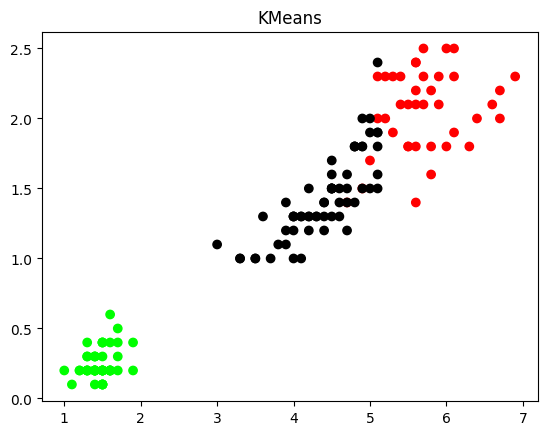

In [74]:
plt.title('KMeans')
plt.scatter(x.Petal_Length,x.Petal_Width,c=colormap[KMeans_label])

In [75]:
from sklearn.metrics import silhouette_score

In [76]:
inertia=model.inertia_
silhouette_avg=silhouette_score(x,KMeans_labels)

print("\nperformance Metrics for K-Means Clustering:")
print(f"- Inertia (sum of squared distances): {inertia:.2f}")
print(f"- Silhouette Score: {silhouette_avg:.4f}")


performance Metrics for K-Means Clustering:
- Inertia (sum of squared distances): 78.92
- Silhouette Score: 0.5486


In [77]:
from sklearn.mixture import GaussianMixture
em = GaussianMixture(n_components=3, random_state=0)
gmm = em.fit(x)
gmm

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,0


In [78]:
y_cluster_pred = gmm.predict(x)
y_cluster_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

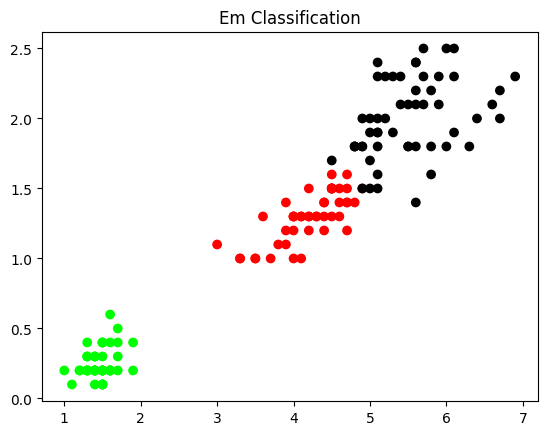

In [79]:
plt.title("Em Classification")
plt.scatter(x.Petal_Length,x.Petal_Width,c=colormap[y_cluster_pred])

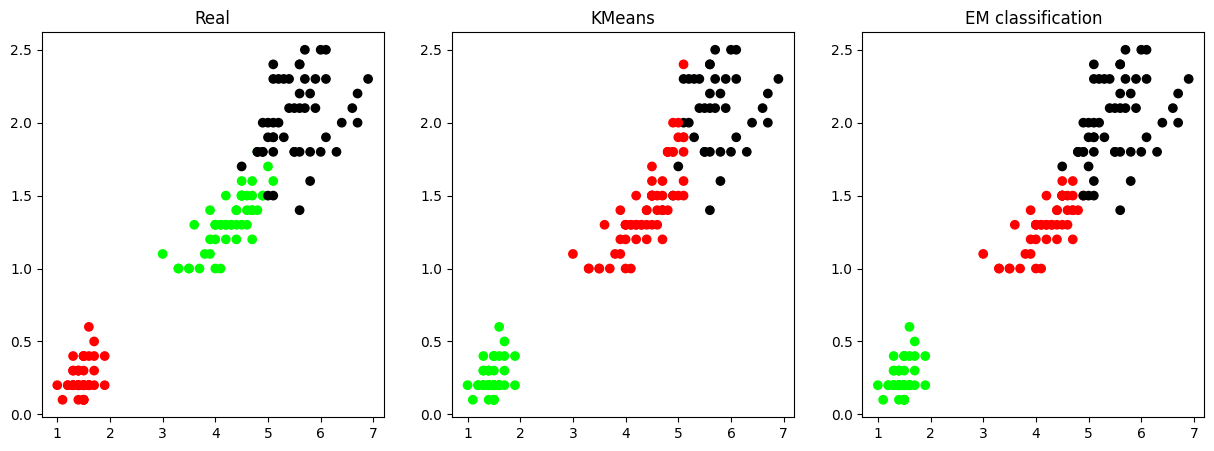

In [80]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
colormap=np.array(['red','lime','black'])
plt.title('Real')
plt.scatter(x.Petal_Length,x.Petal_Width,c=colormap[y])
plt.subplot(1,3,2)
plt.title('KMeans')
plt.scatter(x.Petal_Length,x.Petal_Width,c=colormap[KMeans_labels])
plt.subplot(1,3,3)
plt.title('EM classification')
plt.scatter(x.Petal_Length,x.Petal_Width,c=colormap[y_cluster_pred])

In [81]:
dc = pd.read_csv(r"C:\Users\ADMIN\Downloads\Clustering_Data (1).csv")

In [82]:
dc

,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679
...,...,...
495,59.976983,169.679741
496,66.423814,174.625574
497,53.604698,161.919208
498,50.433644,160.794875


In [83]:
model = KMeans(n_clusters=4,random_state=0)
kmm = model.fit(dc)
kmm

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [84]:
KMeans_label1 = kmm.predict(dc)
KMeans_label1

array([0, 0, 2, 2, 0, 2, 3, 2, 3, 1, 3, 0, 3, 1, 2, 2, 0, 2, 1, 2, 2, 0,
       3, 1, 2, 1, 0, 3, 1, 3, 3, 3, 0, 3, 3, 0, 1, 3, 1, 0, 1, 3, 2, 0,
       3, 0, 3, 2, 0, 0, 1, 1, 3, 3, 2, 3, 3, 1, 1, 0, 0, 1, 0, 0, 0, 3,
       2, 0, 2, 3, 1, 2, 1, 0, 1, 0, 3, 3, 2, 2, 1, 2, 1, 3, 2, 3, 1, 1,
       0, 1, 1, 1, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1, 0, 1, 2, 2, 2, 0, 2, 1,
       1, 3, 1, 1, 0, 1, 0, 2, 3, 0, 3, 1, 0, 0, 1, 0, 0, 0, 0, 1, 2, 1,
       3, 1, 1, 1, 2, 0, 2, 3, 0, 0, 0, 0, 3, 1, 3, 2, 3, 1, 1, 0, 2, 2,
       2, 3, 3, 0, 2, 2, 0, 2, 0, 0, 3, 3, 0, 2, 1, 3, 0, 1, 0, 3, 3, 1,
       3, 1, 1, 1, 0, 0, 3, 2, 2, 1, 3, 0, 3, 1, 0, 3, 1, 3, 3, 1, 2, 3,
       2, 1, 1, 2, 2, 3, 2, 3, 3, 2, 3, 3, 2, 0, 0, 0, 2, 0, 3, 1, 1, 1,
       3, 0, 3, 1, 3, 0, 1, 2, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 1, 0, 0, 3,
       2, 0, 1, 1, 2, 0, 2, 3, 2, 3, 0, 1, 2, 1, 1, 3, 1, 3, 2, 2, 0, 1,
       0, 0, 2, 2, 1, 0, 2, 1, 0, 2, 0, 1, 3, 3, 2, 0, 0, 2, 0, 3, 0, 2,
       3, 0, 2, 2, 2, 0, 1, 1, 0, 1, 1, 1, 2, 0, 0,

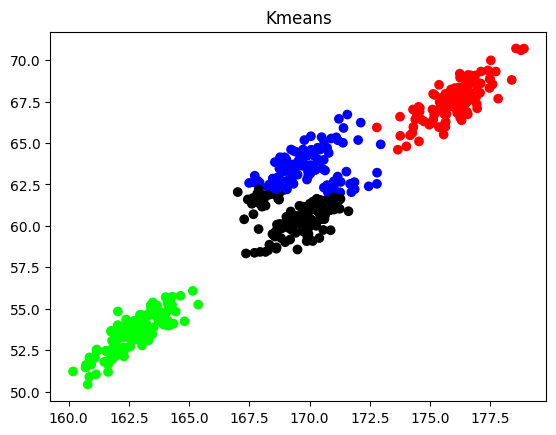

In [85]:
colormap1=np.array(['red','lime','black','blue'])
plt.title('Kmeans')
plt.scatter(dc.Height,dc.Weight,c=colormap1[KMeans_label1])

In [86]:
em=GaussianMixture(n_components=4,random_state=0).fit(dc)
y_cluster_em=em.predict(dc)
y_cluster_em

array([0, 0, 2, 2, 0, 3, 3, 2, 2, 1, 3, 0, 3, 1, 2, 2, 0, 2, 1, 2, 2, 0,
       3, 1, 2, 1, 0, 3, 1, 3, 3, 3, 0, 3, 3, 0, 1, 2, 1, 0, 1, 2, 2, 0,
       3, 0, 2, 2, 0, 0, 1, 1, 3, 2, 2, 3, 3, 1, 1, 0, 0, 1, 0, 0, 0, 3,
       2, 0, 2, 3, 1, 2, 1, 0, 1, 0, 3, 3, 2, 2, 1, 2, 1, 2, 2, 3, 1, 1,
       0, 1, 1, 1, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1, 0, 1, 2, 2, 3, 0, 2, 1,
       1, 3, 1, 1, 0, 1, 0, 2, 3, 0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 1, 2, 1,
       3, 1, 1, 1, 2, 0, 2, 3, 0, 0, 0, 0, 3, 1, 2, 2, 3, 1, 1, 0, 2, 2,
       2, 3, 3, 0, 3, 2, 0, 2, 0, 0, 3, 3, 0, 2, 1, 3, 0, 1, 0, 3, 2, 1,
       2, 1, 1, 1, 0, 0, 0, 2, 3, 1, 3, 0, 3, 1, 0, 3, 1, 3, 3, 1, 2, 3,
       2, 1, 1, 2, 3, 3, 2, 3, 3, 2, 3, 3, 3, 0, 0, 0, 2, 0, 3, 1, 1, 1,
       2, 0, 3, 1, 3, 0, 1, 2, 1, 3, 3, 3, 3, 3, 2, 2, 2, 3, 1, 0, 0, 3,
       3, 0, 1, 1, 2, 0, 2, 2, 2, 3, 0, 1, 2, 1, 1, 3, 1, 3, 2, 2, 0, 1,
       0, 0, 2, 2, 1, 0, 2, 1, 0, 3, 0, 1, 3, 3, 2, 0, 0, 2, 0, 3, 0, 3,
       3, 0, 2, 2, 2, 0, 1, 1, 0, 1, 1, 1, 2, 0, 0,

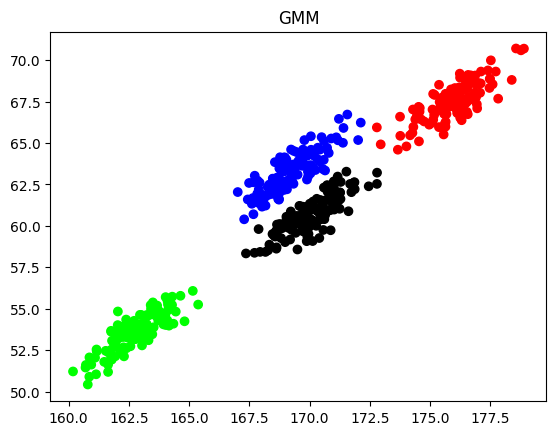

In [87]:
plt.title('GMM')
plt.scatter(dc.Height,dc.Weight,c=colormap1[y_cluster_em])

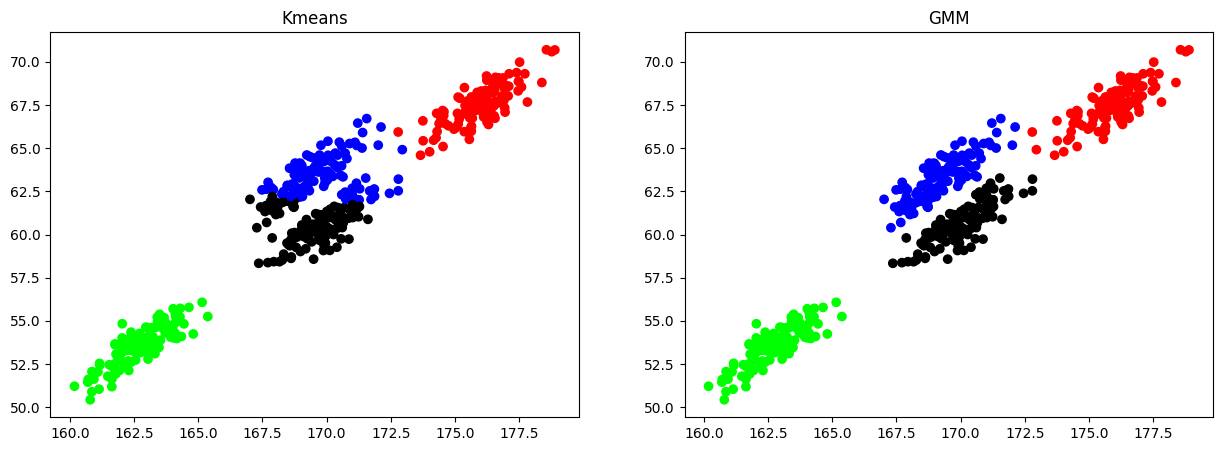

In [88]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Kmeans')
plt.scatter(dc.Height,dc.Weight,c=colormap1[KMeans_label1])
plt.subplot(1,2,2)
plt.title('GMM')
plt.scatter(dc.Height,dc.Weight,c=colormap1[y_cluster_em])